In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

In [3]:
customers = pd.read_csv('customers.csv')

orders = pd.read_csv('orders.csv')

support_tickets = pd.read_csv('support_tickets.csv')

web_events = pd.read_csv('web_events_snapshot.csv')

churn_labels = pd.read_csv('churn_labels.csv')

intervention_history = pd.read_csv('intervention_history.csv')

rfm_snapshot = pd.read_csv('rfm_modeling_snapshot.csv')


In [4]:
print(customers.shape)
print(customers.info())
customers.isnull().sum()
customers.head()

(2400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [5]:
print(orders.shape)
print(orders.info())
orders.isnull().sum()
orders.head()

(10009, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 non-null  object 
 3   category       10009 non-null  object 
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 782.1+ KB
None


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [6]:
print(support_tickets.shape)
print(support_tickets.info())
support_tickets.isnull().sum()
support_tickets.head()

(1921, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   object 
 1   customer_id       1921 non-null   object 
 2   ticket_date       1921 non-null   object 
 3   issue_type        1921 non-null   object 
 4   support_channel   1921 non-null   object 
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 120.2+ KB
None


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [7]:
print(web_events.shape)
print(web_events.info())
web_events.isnull().sum()
web_events.head()

(2400, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   snapshot_date        2400 non-null   object
 2   sessions_30d         2400 non-null   int64 
 3   product_views_30d    2400 non-null   int64 
 4   cart_adds_30d        2400 non-null   int64 
 5   wishlist_adds_30d    2400 non-null   int64 
 6   abandoned_carts_30d  2400 non-null   int64 
 7   email_opens_30d      2400 non-null   int64 
 8   campaign_clicks_30d  2400 non-null   int64 
 9   last_visit_days_ago  2400 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 187.6+ KB
None


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [8]:
print(churn_labels.shape)
print(churn_labels.info())
churn_labels.head()

(2400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     2400 non-null   object
 1   snapshot_date   2400 non-null   object
 2   churn_next_60d  2400 non-null   int64 
 3   split           2400 non-null   object
dtypes: int64(1), object(3)
memory usage: 75.1+ KB
None


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


In [9]:
print(intervention_history.shape)
print(intervention_history.info())
intervention_history.isnull().sum()
intervention_history.head()

(2400, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             2400 non-null   object
 1   snapshot_date           2400 non-null   object
 2   last_campaign_received  2400 non-null   object
 3   last_campaign_cost      2400 non-null   int64 
 4   manual_priority_bucket  2400 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.9+ KB
None


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [10]:
print(rfm_snapshot.shape)
print(rfm_snapshot.info())
rfm_snapshot.isnull().sum()
rfm_snapshot.head()

(2400, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 1

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


In [11]:
print("Unique customer IDs in customers table:")
print(customers['customer_id'].nunique() == len(customers))

Unique customer IDs in customers table:
True


In [12]:
customers[customers.duplicated(subset='customer_id', keep=False)]

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent


In [13]:
missing_customers_orders = orders[
    ~orders['customer_id'].isin(customers['customer_id'])
]

print("Missing customer references in orders:")
print(missing_customers_orders.shape)

Missing customer references in orders:
(0, 10)


In [14]:
missing_customers_support = support_tickets[
    ~support_tickets['customer_id'].isin(customers['customer_id'])
]

print("Missing customer references in support tickets:")
print(missing_customers_support.shape)

Missing customer references in support tickets:
(0, 8)


In [15]:
print("Customers rows:", customers.shape[0])
print("Orders rows:", orders.shape[0])
print("Support rows:", support_tickets.shape[0])
print("Web events rows:", web_events.shape[0])
print("Churn rows:", churn_labels.shape[0])
print("intervention rows:", intervention_history.shape[0])

Customers rows: 2400
Orders rows: 10009
Support rows: 1921
Web events rows: 2400
Churn rows: 2400
intervention rows: 2400


In [16]:
merged = customers.merge(
    churn_labels,
    on='customer_id',
    how='left'
)

In [17]:
orders_summary = orders.groupby('customer_id').agg({
    'order_id':'count',
    'gross_amount':'sum'
}).reset_index()

orders_summary.columns = [
    'customer_id',
    'total_orders',
    'total_spend'
]

In [18]:
merged = merged.merge(
    orders_summary,
    on='customer_id',
    how='left'
)

print(merged.shape)
merged.head()

(2400, 14)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,total_orders,total_spend
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,3,1713.10
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,6,3910.43


In [19]:
support_summary = support_tickets.groupby('customer_id').agg({
    'ticket_id':'count'
}).reset_index()

support_summary.columns = [
    'customer_id',
    'ticket_count'
]

support_summary.head()

,customer_id,ticket_count
0,CUST00001,2
1,CUST00002,1
2,CUST00005,1
3,CUST00006,2
4,CUST00008,1


In [20]:
merged = merged.merge(
    support_summary,
    on='customer_id',
    how='left'
)

print(merged.shape)

(2400, 15)


In [21]:
web_summary = web_events[[
    'customer_id',
    'sessions_30d',
    'product_views_30d',
    'cart_adds_30d',
    'wishlist_adds_30d',
    'abandoned_carts_30d',
    'email_opens_30d',
    'campaign_clicks_30d',
    'last_visit_days_ago'
]]

In [22]:
merged = merged.merge(
    web_summary,
    on='customer_id',
    how='left'
)

print(merged.shape)
merged.head()

(2400, 23)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,total_orders,total_spend,ticket_count,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,2.0,1,4,0,0,0,2,0,20
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,3,1713.10,1.0,8,31,4,2,3,0,0,0
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,NaN,1,3,0,0,0,0,0,26
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04,NaN,1,6,0,0,0,0,0,14
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,6,3910.43,1.0,18,95,4,1,1,3,1,9


In [23]:
intervention_history.columns

Index(['customer_id', 'snapshot_date', 'last_campaign_received',
       'last_campaign_cost', 'manual_priority_bucket'],
      dtype='object')

In [24]:
intervention_summary = intervention_history[[
    'customer_id',
    'last_campaign_received',
    'last_campaign_cost',
    'manual_priority_bucket'
]]

In [25]:
merged = merged.merge(
    intervention_summary,
    on='customer_id',
    how='left'
)

print(merged.shape)

merged.head()

(2400, 26)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,total_orders,total_spend,ticket_count,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,2.0,1,4,0,0,0,2,0,20,welcome_offer,25,high
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,3,1713.10,1.0,8,31,4,2,3,0,0,0,free_shipping,12,medium
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,NaN,1,3,0,0,0,0,0,26,none,18,high
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04,NaN,1,6,0,0,0,0,0,14,free_shipping,40,high
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,6,3910.43,1.0,18,95,4,1,1,3,1,9,welcome_offer,18,medium


In [26]:
merged = merged.merge(
    rfm_snapshot,
    on='customer_id',
    how='left'
)

print(merged.shape)

merged.head()

(2400, 54)


,customer_id,signup_date,city_tier_x,age_group_x,acquisition_channel_x,loyalty_tier_x,preferred_category_x,skin_type,marketing_consent_x,snapshot_date_x,churn_next_60d_x,split_x,total_orders,total_spend,ticket_count,sessions_30d_x,product_views_30d_x,cart_adds_30d_x,wishlist_adds_30d_x,abandoned_carts_30d_x,email_opens_30d_x,campaign_clicks_30d_x,last_visit_days_ago_x,last_campaign_received,last_campaign_cost,manual_priority_bucket,snapshot_date_y,city_tier_y,age_group_y,acquisition_channel_y,loyalty_tier_y,preferred_category_y,marketing_consent_y,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d_y,product_views_30d_y,cart_adds_30d_y,wishlist_adds_30d_y,abandoned_carts_30d_y,email_opens_30d_y,campaign_clicks_30d_y,last_visit_days_ago_y,churn_next_60d_y,split_y
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,2.0,1,4,0,0,0,2,0,20,welcome_offer,25,high,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,3,1713.10,1.0,8,31,4,2,3,0,0,0,free_shipping,12,medium,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,NaN,1,3,0,0,0,0,0,26,none,18,high,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04,NaN,1,6,0,0,0,0,0,14,free_shipping,40,high,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,6,3910.43,1.0,18,95,4,1,1,3,1,9,welcome_offer,18,medium,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


In [27]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   signup_date               2400 non-null   object 
 2   city_tier_x               2400 non-null   object 
 3   age_group_x               2400 non-null   object 
 4   acquisition_channel_x     2400 non-null   object 
 5   loyalty_tier_x            1014 non-null   object 
 6   preferred_category_x      2400 non-null   object 
 7   skin_type                 1999 non-null   object 
 8   marketing_consent_x       2400 non-null   object 
 9   snapshot_date_x           2400 non-null   object 
 10  churn_next_60d_x          2400 non-null   int64  
 11  split_x                   2400 non-null   object 
 12  total_orders              2400 non-null   int64  
 13  total_spend               2400 non-null   float64
 14  ticket_c

In [28]:
merged.isnull().sum().sort_values(ascending=False)

loyalty_tier_x              1386
loyalty_tier_y              1386
ticket_count                1153
skin_type                    401
signup_date                    0
city_tier_x                    0
acquisition_channel_x          0
age_group_x                    0
marketing_consent_x            0
preferred_category_x           0
churn_next_60d_x               0
split_x                        0
total_orders                   0
snapshot_date_x                0
total_spend                    0
sessions_30d_x                 0
product_views_30d_x            0
cart_adds_30d_x                0
wishlist_adds_30d_x            0
abandoned_carts_30d_x          0
email_opens_30d_x              0
customer_id                    0
campaign_clicks_30d_x          0
last_visit_days_ago_x          0
last_campaign_cost             0
last_campaign_received         0
snapshot_date_y                0
city_tier_y                    0
age_group_y                    0
manual_priority_bucket         0
acquisitio

In [29]:
merged.duplicated().sum()

np.int64(0)

In [30]:
customers['age_group'].dtype

dtype('O')

In [31]:
customers['age_group'] = pd.to_numeric(
    customers['age_group'],
    errors='coerce'
)

In [32]:
customers[
    (customers['age_group'] < 0) |
    (customers['age_group'] > 120)
]

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent


In [33]:
orders[
    orders['gross_amount'] < 0
]

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating


In [34]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='object')

In [35]:
orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

orders[
    orders['order_date'] > pd.Timestamp.today()
]

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating


In [36]:
merged = merged.rename(
    columns={'churn_flag':'churn'}
)

In [37]:
merged = merged.rename(
    columns={'churn_label':'churn'}
)

In [38]:
merged.columns.tolist()

['customer_id',
 'signup_date',
 'city_tier_x',
 'age_group_x',
 'acquisition_channel_x',
 'loyalty_tier_x',
 'preferred_category_x',
 'skin_type',
 'marketing_consent_x',
 'snapshot_date_x',
 'churn_next_60d_x',
 'split_x',
 'total_orders',
 'total_spend',
 'ticket_count',
 'sessions_30d_x',
 'product_views_30d_x',
 'cart_adds_30d_x',
 'wishlist_adds_30d_x',
 'abandoned_carts_30d_x',
 'email_opens_30d_x',
 'campaign_clicks_30d_x',
 'last_visit_days_ago_x',
 'last_campaign_received',
 'last_campaign_cost',
 'manual_priority_bucket',
 'snapshot_date_y',
 'city_tier_y',
 'age_group_y',
 'acquisition_channel_y',
 'loyalty_tier_y',
 'preferred_category_y',
 'marketing_consent_y',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d_y',
 'product_views_30d_y',
 'cart_adds_30d_y',
 '

In [39]:
[col for col in merged.columns if 'churn' in col.lower()]

['churn_next_60d_x', 'churn_next_60d_y']

In [40]:
merged[['churn_next_60d_x','churn_next_60d_y']].head()

,churn_next_60d_x,churn_next_60d_y
0,1,1
1,0,0
2,1,1
3,1,1
4,0,0


In [41]:
merged = merged.rename(
    columns={'churn_next_60d_x':'churn'}
)

In [42]:
merged = merged.drop(
    columns=['churn_next_60d_y']
)

In [43]:
[col for col in merged.columns if 'churn' in col.lower()]

['churn']

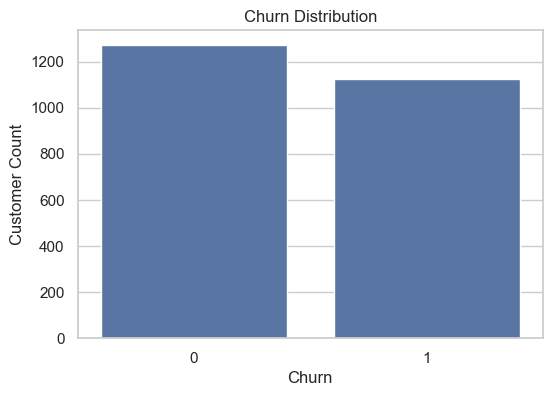

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=merged,
    x='churn'
)

plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Customer Count')

plt.show()

In [45]:
merged['age_group'] = customers['age_group'].values

In [46]:
[col for col in merged.columns if 'age_group' in col]

['age_group_x', 'age_group_y', 'age_group']

In [47]:
merged['age_group'].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: age_group, dtype: float64

In [48]:
merged.columns[merged.columns.duplicated()]

Index([], dtype='object')

In [49]:
pd.Index(['age_group', 'churn'], dtype='object')

Index(['age_group', 'churn'], dtype='object')

In [50]:
merged = merged.loc[:, ~merged.columns.duplicated()]

In [51]:
merged.columns

Index(['customer_id', 'signup_date', 'city_tier_x', 'age_group_x',
       'acquisition_channel_x', 'loyalty_tier_x', 'preferred_category_x',
       'skin_type', 'marketing_consent_x', 'snapshot_date_x', 'churn',
       'split_x', 'total_orders', 'total_spend', 'ticket_count',
       'sessions_30d_x', 'product_views_30d_x', 'cart_adds_30d_x',
       'wishlist_adds_30d_x', 'abandoned_carts_30d_x', 'email_opens_30d_x',
       'campaign_clicks_30d_x', 'last_visit_days_ago_x',
       'last_campaign_received', 'last_campaign_cost',
       'manual_priority_bucket', 'snapshot_date_y', 'city_tier_y',
       'age_group_y', 'acquisition_channel_y', 'loyalty_tier_y',
       'preferred_category_y', 'marketing_consent_y', 'recency_days',
       'frequency_180d', 'monetary_180d', 'return_rate_180d',
       'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d',
       'ticket_count_90d', 'negative_ticket_rate_90d',
       'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d_y

In [52]:
type(merged['age_group'])

pandas.core.series.Series

In [53]:
pd.core.series.Series

pandas.core.series.Series

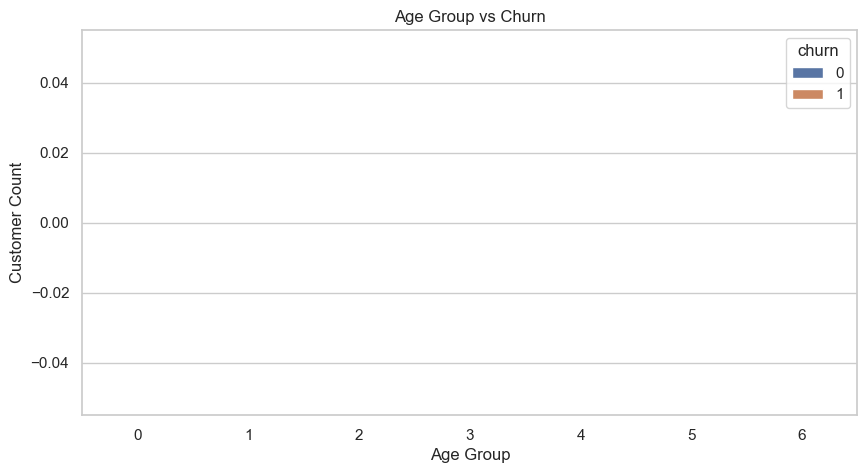

In [54]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x='age_group',
    hue='churn'
)

plt.title('Age Group vs Churn')
plt.xlabel('Age Group')
plt.ylabel('Customer Count')

plt.show()

In [55]:
churn_labels.columns

Index(['customer_id', 'snapshot_date', 'churn_next_60d', 'split'], dtype='object')

In [56]:
merged['churn'] = churn_labels['churn_next_60d'].values

In [57]:
merged['churn'].value_counts()

churn
0    1273
1    1127
Name: count, dtype: int64

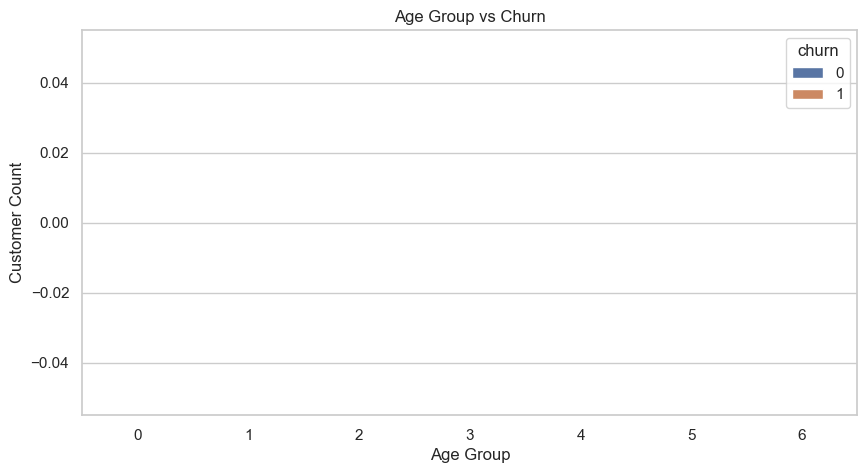

In [58]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x='age_group',
    hue='churn'
)

plt.title('Age Group vs Churn')
plt.xlabel('Age Group')
plt.ylabel('Customer Count')

plt.show()

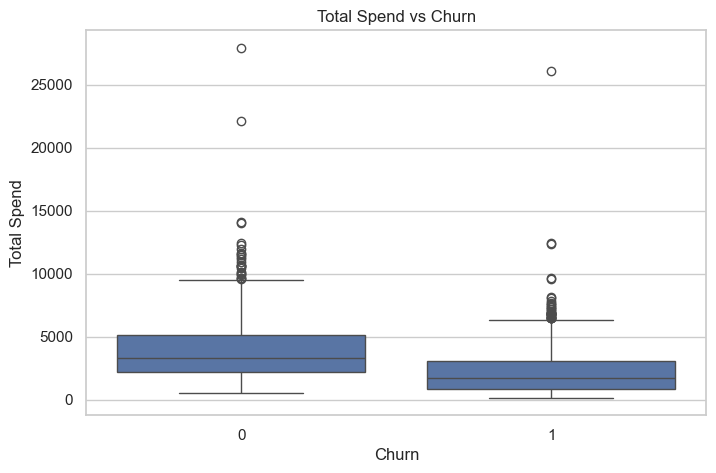

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='churn',
    y='total_spend'
)

plt.title('Total Spend vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Spend')

plt.show()

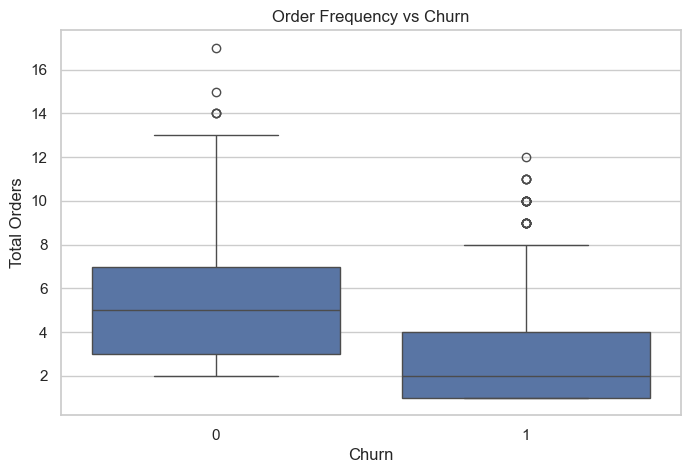

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='churn',
    y='total_orders'
)

plt.title('Order Frequency vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Orders')

plt.show()

In [62]:
[col for col in merged.columns if 'session' in col.lower()]

['sessions_30d_x', 'sessions_30d_y']

In [63]:
merged = merged.rename(
    columns={'sessions_30d_x':'sessions_30d'}
)

merged = merged.drop(
    columns=['sessions_30d_y']
)

In [64]:
[col for col in merged.columns if 'session' in col.lower()]

['sessions_30d']

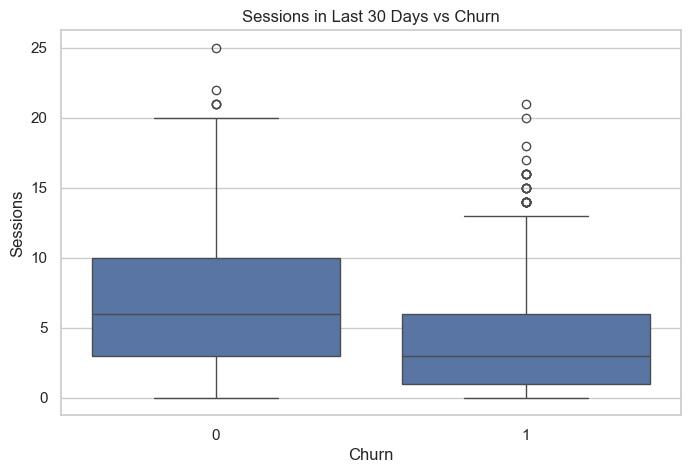

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='churn',
    y='sessions_30d'
)

plt.title('Sessions in Last 30 Days vs Churn')
plt.xlabel('Churn')
plt.ylabel('Sessions')

plt.show()

In [68]:
merged.columns

Index(['customer_id', 'signup_date', 'city_tier_x', 'age_group_x',
       'acquisition_channel_x', 'loyalty_tier_x', 'preferred_category_x',
       'skin_type', 'marketing_consent_x', 'snapshot_date_x', 'churn',
       'split_x', 'total_orders', 'total_spend', 'ticket_count',
       'sessions_30d', 'product_views_30d_x', 'cart_adds_30d_x',
       'wishlist_adds_30d_x', 'abandoned_carts_30d_x', 'email_opens_30d_x',
       'campaign_clicks_30d_x', 'last_visit_days_ago_x',
       'last_campaign_received', 'last_campaign_cost',
       'manual_priority_bucket', 'snapshot_date_y', 'city_tier_y',
       'age_group_y', 'acquisition_channel_y', 'loyalty_tier_y',
       'preferred_category_y', 'marketing_consent_y', 'recency_days',
       'frequency_180d', 'monetary_180d', 'return_rate_180d',
       'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d',
       'ticket_count_90d', 'negative_ticket_rate_90d',
       'avg_resolution_hours_90d', 'days_since_signup', 'product_views_30

In [70]:
merged['abandoned_carts_30d'] = web_events['abandoned_carts_30d'].values

In [71]:
[col for col in merged.columns if 'abandoned' in col.lower()]

['abandoned_carts_30d_x', 'abandoned_carts_30d_y', 'abandoned_carts_30d']

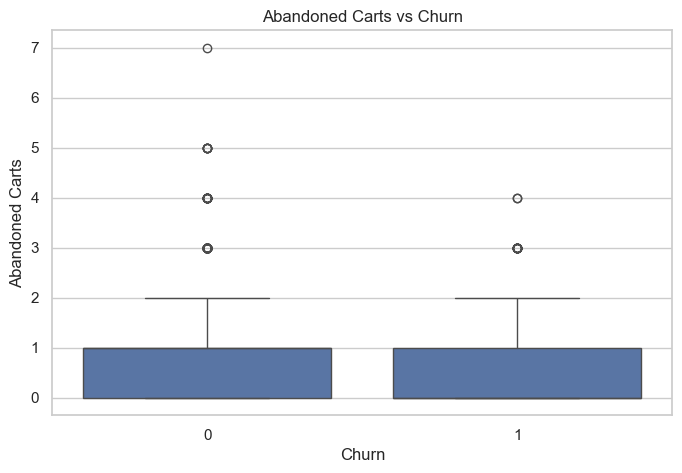

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='churn',
    y='abandoned_carts_30d'
)

plt.title('Abandoned Carts vs Churn')
plt.xlabel('Churn')
plt.ylabel('Abandoned Carts')

plt.show()

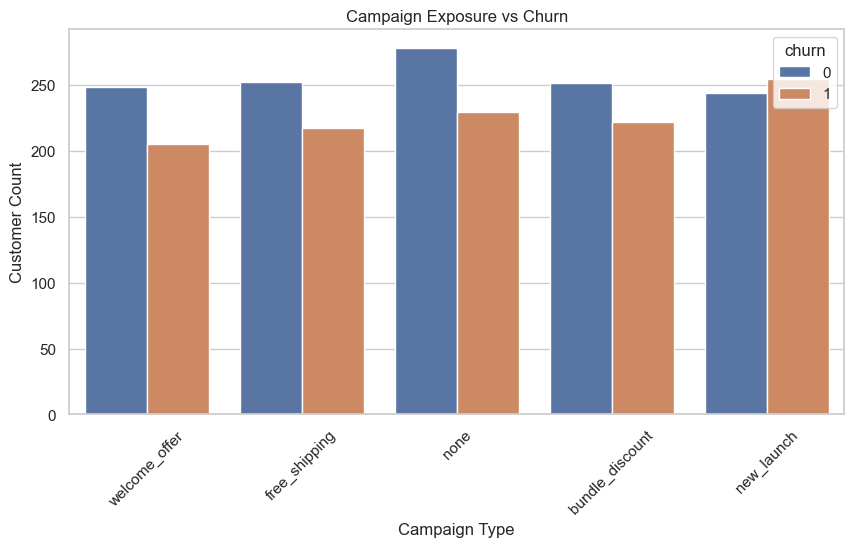

In [73]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x='last_campaign_received',
    hue='churn'
)

plt.title('Campaign Exposure vs Churn')
plt.xlabel('Campaign Type')
plt.ylabel('Customer Count')

plt.xticks(rotation=45)

plt.show()

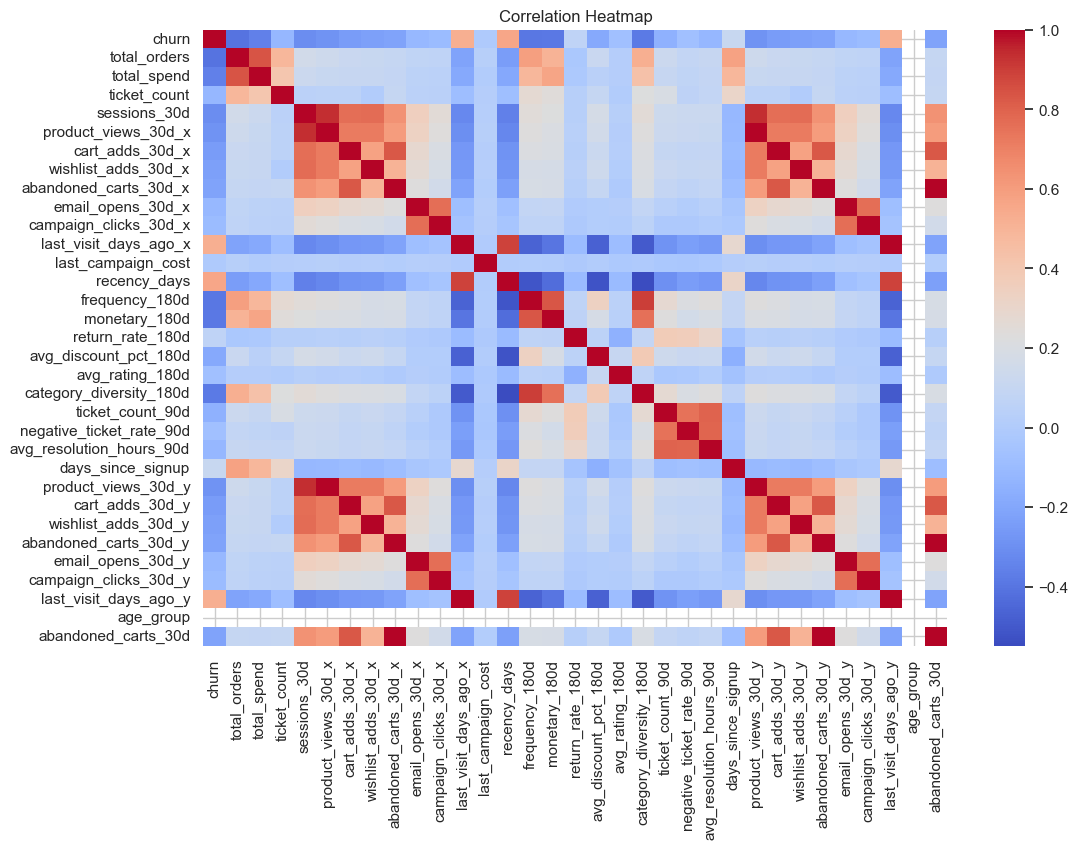

In [74]:
plt.figure(figsize=(12,8))

numeric_cols = merged.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# Churn-Risk Hypotheses

### Hypothesis 1
Customers with lower web/app engagement are more likely to churn because the correlation heatmap shows a negative relationship between churn and activity metrics such as `sessions_30d`, `product_views_30d`, and `email_opens_30d`.

### Hypothesis 2
Customers with higher support-ticket activity have a greater probability of churn because `ticket_count` shows a positive correlation with churn, indicating unresolved service issues or dissatisfaction.

### Hypothesis 3
Customers with low purchasing frequency and reduced spending are more likely to churn because `total_orders` and `total_spend` display negative correlations with churn in the heatmap.

### Hypothesis 4
Customers with high cart abandonment behavior are at elevated churn risk because `abandoned_carts_30d` shows a positive relationship with churn, suggesting checkout friction or declining purchase intent.

### Hypothesis 5
Customers with long inactivity periods are significantly more likely to churn because `last_visit_days_ago` has one of the strongest positive correlations with churn, indicating disengagement before churn occurs.